In [61]:
# Imports necessary programs, as well as the dataset to be worked with.
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
cafedata = pd.DataFrame(pd.read_csv('/Users/Xsx/Desktop/dirty_cafe_sales 2.csv'))
pd.set_option('display.max_columns', None)

In [62]:
# A preliminary sample of our dirty data to get a taste of what we're looking at. Unknowns, errors, and the like are everywhere here. 
cafedata.sample(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
3996,TXN_5352739,Sandwich,4,4.0,UNKNOWN,NaN,NaN,2023-07-31
1164,TXN_2761542,Cookie,4,1.0,4.0,NaN,NaN,2023-10-15
5473,TXN_5826333,Cookie,1,1.0,1.0,Cash,NaN,2023-05-14
6297,TXN_6503884,Juice,1,3.0,3.0,Cash,In-store,2023-05-28
4553,TXN_5166412,UNKNOWN,4,1.0,4.0,UNKNOWN,Takeaway,2023-06-17
7306,TXN_6234882,Cookie,4,1.0,4.0,Credit Card,ERROR,2023-01-01
2906,TXN_6684202,Sandwich,1,4.0,4.0,NaN,NaN,2023-07-31
6327,TXN_4900574,Juice,3,3.0,9.0,NaN,NaN,2023-05-06
6885,TXN_6047710,Smoothie,3,4.0,12.0,NaN,Takeaway,2023-06-16
9973,TXN_7936002,Salad,2,5.0,10.0,Digital Wallet,NaN,2023-01-26


In [63]:
# Sorts values by Transaction ID to obtain an estimated date order, and replaces all missing values with np.nan to make later calculations much easier.
cafedata.sort_values(by='Transaction ID', inplace=True)
cafedata.reset_index(drop=True, inplace=True)
cafedata.replace(['UNKNOWN', 'ERROR'], np.nan, inplace=True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1000555,Tea,1,1.5,1.5,Credit Card,In-store,2023-10-19
1,TXN_1001832,Salad,2,5.0,10.0,Cash,Takeaway,NaN
2,TXN_1002457,Cookie,5,1.0,5.0,Digital Wallet,Takeaway,2023-09-29
3,TXN_1003246,Juice,2,3.0,6.0,NaN,NaN,2023-02-15
4,TXN_1004184,Smoothie,1,4.0,4.0,Credit Card,In-store,2023-05-18
...,...,...,...,...,...,...,...,...
9995,TXN_9996968,Sandwich,1,NaN,4.0,Cash,In-store,2023-10-14
9996,TXN_9997263,Cookie,2,1.0,2.0,NaN,NaN,2023-03-05
9997,TXN_9997620,Cookie,2,1.0,2.0,Cash,NaN,2023-12-11
9998,TXN_9999113,Juice,4,3.0,12.0,Cash,Takeaway,2023-05-27


In [64]:
# Sets the numeric values to floats, 
cafedata[['Quantity', 'Total Spent', 'Price Per Unit']] = cafedata[['Quantity', 'Total Spent', 'Price Per Unit']].astype(float)
# Establishes a canon price guide according to the website source, then fills accordingly for item price when it can.
price_guide = {
    'Sandwich': 4.0,
    'Tea': 1.5,
    'Coffee': 2.0,
    'Salad': 5.0,
    'Cake': 3.0,
    'Cookie': 1.0,
    'Smoothie': 4.0,
    'Juice': 3.0
}
for i in range(len(cafedata)):
    item_name = cafedata.loc[i, 'Item']
    if item_name in price_guide:
        cafedata.at[i, 'Price Per Unit'] = price_guide[item_name]

In [65]:
#then uses cols' dependence on each other to fill in missing values when only one of three values is missing.
cafedata.fillna({'Quantity': cafedata['Total Spent'] / cafedata['Price Per Unit']}, inplace=True)
cafedata.fillna({'Price Per Unit': cafedata['Total Spent'] / cafedata['Quantity']}, inplace=True)
cafedata.fillna({'Total Spent': cafedata['Quantity'] * cafedata['Price Per Unit']}, inplace=True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1000555,Tea,1.0,1.5,1.5,Credit Card,In-store,2023-10-19
1,TXN_1001832,Salad,2.0,5.0,10.0,Cash,Takeaway,NaN
2,TXN_1002457,Cookie,5.0,1.0,5.0,Digital Wallet,Takeaway,2023-09-29
3,TXN_1003246,Juice,2.0,3.0,6.0,NaN,NaN,2023-02-15
4,TXN_1004184,Smoothie,1.0,4.0,4.0,Credit Card,In-store,2023-05-18
...,...,...,...,...,...,...,...,...
9995,TXN_9996968,Sandwich,1.0,4.0,4.0,Cash,In-store,2023-10-14
9996,TXN_9997263,Cookie,2.0,1.0,2.0,NaN,NaN,2023-03-05
9997,TXN_9997620,Cookie,2.0,1.0,2.0,Cash,NaN,2023-12-11
9998,TXN_9999113,Juice,4.0,3.0,12.0,Cash,Takeaway,2023-05-27


In [66]:
cafedata['Transaction Date'].isnull().mean()

np.float64(0.046)

In [67]:
# Fills null dates with the previous transaction's date to attempt to get the values close enough - unfortunately, the Transaction IDs aren't in date order! 
# Then we check the missing value in datetime is only 4.6%, so we directly drop them to keep accuracy

cafedata.dropna(subset=['Transaction Date'], inplace=True)
cafedata.reset_index(drop=True, inplace=True)

In [68]:
# For uniquely priced items, retroactively sets the item value from the price per item.
for i in range(len(cafedata)):
    if cafedata['Price Per Unit'].values[i] in [1.0, 1.5, 2.0, 5.0]:
        cafedata['Item'].values[i] = list(price_guide.keys())[list(price_guide.values()).index(cafedata['Price Per Unit'].values[i])]

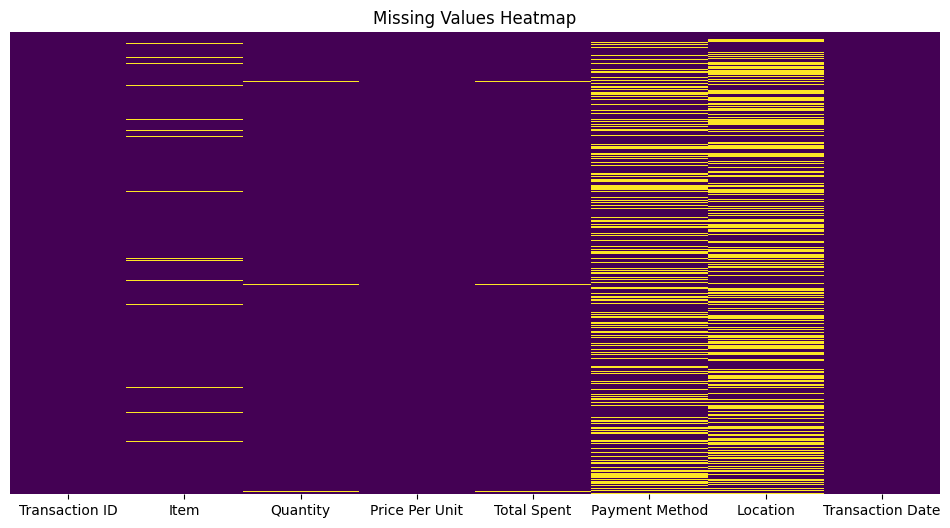

In [69]:
# Visualize missingness
plt.figure(figsize=(12,6))
sns.heatmap(cafedata.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [70]:
# Investigating the remaining missing Quantity data, we can reason with a few remaining missing data points and impute the rest.
cafedata[cafedata['Price Per Unit'].isna()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
82,TXN_1082717,NaN,NaN,NaN,9.0,Digital Wallet,In-store,2023-12-13
192,TXN_1208561,NaN,NaN,NaN,20.0,Credit Card,NaN,2023-08-19
2803,TXN_3611851,NaN,4.0,NaN,NaN,Credit Card,NaN,2023-02-09
6802,TXN_7376255,NaN,NaN,NaN,25.0,NaN,In-store,2023-05-27
6959,TXN_7524977,NaN,4.0,NaN,NaN,NaN,NaN,2023-12-09
9166,TXN_9646000,NaN,2.0,NaN,NaN,NaN,In-store,2023-12-14


In [71]:
# Notably, one entry for Total Spent is 25.0, which means it must be 5 salads purchased. (5 items max, only salad is $5)
# Additionally, Total Spent at 9.0 must be three $3 items thanks to the 5 quantity maximum, though we don't know the specific item.

cafedata.at[82, 'Price Per Unit'] = 3.0
cafedata.at[82, 'Quantity'] = 3.0

cafedata.at[6802, 'Price Per Unit'] = 5.0
cafedata.at[6802, 'Quantity'] = 5.0
cafedata.at[6802, 'Item'] = 'Salad'

In [72]:
cafedata[cafedata['Total Spent'].isna()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
548,TXN_1547245,Sandwich,NaN,4.0,NaN,NaN,Takeaway,2023-09-11
1016,TXN_1975184,Coffee,NaN,2.0,NaN,Digital Wallet,NaN,2023-01-15
1082,TXN_2023651,Sandwich,NaN,4.0,NaN,Cash,In-store,2023-05-25
1551,TXN_2428781,Salad,NaN,5.0,NaN,NaN,In-store,2023-05-09
1686,TXN_2546684,Juice,NaN,3.0,NaN,Digital Wallet,Takeaway,2023-04-08
2133,TXN_2962976,Juice,NaN,3.0,NaN,NaN,NaN,2023-03-17
2400,TXN_3229409,Juice,NaN,3.0,NaN,Cash,Takeaway,2023-04-15
2419,TXN_3251829,Tea,NaN,1.5,NaN,Digital Wallet,In-store,2023-07-25
2803,TXN_3611851,NaN,4.0,NaN,NaN,Credit Card,NaN,2023-02-09
3834,TXN_4550558,Cookie,NaN,1.0,NaN,Credit Card,In-store,2023-08-04


In [73]:
#location and payment method are important for anlaysis in customer behavior, while total spent on each item is critical in revenue insight.
#There exist a strict logic that quantity*price per unit = total spent, so it is better to fill in the quantity & unit price first, and then calculate the total spent.
# So we apply KNN on location, payment method, price per unit, and quantity

import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
#Since the date are all accuracy, adding cols of month, day, weekday may result in better performance in KNN
cafedata['Transaction Date'] = pd.to_datetime(cafedata['Transaction Date'], errors='coerce')
cafedata['Month'] = cafedata['Transaction Date'].dt.month
cafedata['Day'] = cafedata['Transaction Date'].dt.day
cafedata['Weekday'] = cafedata['Transaction Date'].dt.weekday

# Encode categorical variables into numeric codes for KNN processing.
# We store the mapping (codes and uniques) to decode them back to text later.
cafedata['Pay_Code'], pay_map = pd.factorize(cafedata['Payment Method'])
cafedata['Loc_Code'], loc_map = pd.factorize(cafedata['Location'])
cafedata.loc[cafedata['Pay_Code'] == -1, 'Pay_Code'] = np.nan
cafedata.loc[cafedata['Loc_Code'] == -1, 'Loc_Code'] = np.nan

# Handle missing values in 'Item' by labeling them as 'Unknown' before One-Hot Encoding.
# This ensures that rows with missing Items have a distinct feature representation for KNN.
cafedata['Item'] = cafedata['Item'].fillna('Unknown')
item_dummies = pd.get_dummies(cafedata['Item'], dummy_na=False).astype(int)

knn_features = ['Price Per Unit', 'Quantity', 'Month', 'Day', 'Weekday', 'Pay_Code', 'Loc_Code']
knn_input_data = pd.concat([cafedata[knn_features], item_dummies], axis=1)

imputer = KNNImputer(n_neighbors=5)
imputed_array = imputer.fit_transform(knn_input_data)
imputed_df = pd.DataFrame(imputed_array, columns=knn_input_data.columns, index=cafedata.index)


# For quantity, we do round up.
cafedata['Quantity'] = imputed_df['Quantity'].round(0)
# For unit price, we only have some specific choices. So after KNN, the value should be rounded up to its nearest choice. 
valid_prices = [1.0, 1.5, 2.0, 3.0, 4.0, 5.0]
cafedata['Price Per Unit'] = imputed_df['Price Per Unit'].apply(lambda x: min(valid_prices, key=lambda p: abs(p - x)))
cafedata['Total Spent'] = cafedata['Quantity'] * cafedata['Price Per Unit']

# Restore imputed numeric codes back to categorical labels.
# Since KNN returns continuous values (e.g., 0.6), we round them to the nearest 
# integer index before mapping them back to their original text labels.
def restore_category(code_series, original_map):
    rounded_codes = code_series.round(0).astype(int)
    max_idx = len(original_map) - 1
    rounded_codes = rounded_codes.clip(0, max_idx)
    return [original_map[i] for i in rounded_codes]

cafedata['Payment Method'] = restore_category(imputed_df['Pay_Code'], pay_map)
cafedata['Location'] = restore_category(imputed_df['Loc_Code'], loc_map)

# remove temp cols
cafedata.drop(columns=['Pay_Code', 'Loc_Code'], inplace=True)



In [74]:
# At this point, we are out of values to fill in with other information. 
# A key decision: impute values and risk getting false data, remove missing values and lose a lot of data, or mark as unknown?
# For payment method and location, we will keep null, because they are not as essential for computing total revenue. (Can use rate metrics to infer later on)
# For numeric data, it's time to impute! Out of 10,000 transactions, only 23 are missing Total Spent data, which means inferrals should not overall impact data analysis.
# For this imputation, we will use K-Nearest Neighbors, and thus will have to prep our categorical variables as dummies.
# cafedata['Year'] = cafedata['Transaction Date'].dt.year
# cafedata['Month'] = cafedata['Transaction Date'].dt.month
# cafedata['Weekday'] = cafedata['Transaction Date'].dt.weekday
# cafedata['Day'] = cafedata['Transaction Date'].dt.day
# cafedata = pd.concat([cafedata, pd.get_dummies(cafedata['Item']).astype(int)], axis=1)
# cafedata = pd.concat([cafedata, pd.get_dummies(cafedata['Payment Method']).astype(int)], axis=1)
# cafedata = pd.concat([cafedata, pd.get_dummies(cafedata['Location']).astype(int)], axis=1)

In [75]:
# # KNN Imputation for Numerical Features
# from sklearn.impute import KNNImputer

# # Select numerical columns (after removing near-zero variance features)
# num_cols = cafedata.select_dtypes(include=[np.number]).columns

# # Initialize the imputer
# # KNNImpute, unfortunately, uses a mean among k neighbors rather than a mode, so for distinct variables we'll have to use the single nearest neighbor.
# imputer = KNNImputer(n_neighbors=1)
# cafedata[num_cols] = imputer.fit_transform(cafedata[num_cols])

# print("Missing values after KNN imputation (numerical):")
# print(cafedata[num_cols].isnull().sum())

In [76]:
#turn the item labled as 'Unknown' back to NaN
cafedata['Item'] = cafedata['Item'].replace('Unknown', np.nan)

In [77]:
# We run the mapping again to fill those items with unique price
for i in range(len(cafedata)):
    if cafedata['Price Per Unit'].values[i] in [1.0, 1.5, 2.0, 5.0]:
        cafedata['Item'].values[i] = list(price_guide.keys())[list(price_guide.values()).index(cafedata['Price Per Unit'].values[i])]

In [78]:
#observe remaining nan
processed_cols = ['Quantity', 'Price Per Unit', 'Total Spent']
remaining_nan = cafedata.drop(columns=processed_cols).isnull().sum()
print(remaining_nan[remaining_nan > 0])

Item    452
dtype: int64


In [79]:
cafedata.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month,Day,Weekday
0,TXN_1000555,Tea,1.0,1.5,1.5,Credit Card,In-store,2023-10-19,10,19,3
1,TXN_1002457,Cookie,5.0,1.0,5.0,Digital Wallet,Takeaway,2023-09-29,9,29,4
2,TXN_1003246,Juice,2.0,3.0,6.0,Digital Wallet,In-store,2023-02-15,2,15,2
3,TXN_1004184,Smoothie,1.0,4.0,4.0,Credit Card,In-store,2023-05-18,5,18,3
4,TXN_1004563,Tea,5.0,1.5,7.5,Credit Card,In-store,2023-10-28,10,28,5
5,TXN_1005331,Coffee,1.0,2.0,2.0,Digital Wallet,Takeaway,2023-11-04,11,4,5
6,TXN_1005377,Cake,5.0,3.0,15.0,Digital Wallet,Takeaway,2023-06-03,6,3,5
7,TXN_1005472,Coffee,4.0,2.0,8.0,Credit Card,Takeaway,2023-04-21,4,21,4
8,TXN_1006942,Salad,1.0,5.0,5.0,Credit Card,In-store,2023-11-30,11,30,3
9,TXN_1007347,Salad,4.0,5.0,20.0,Digital Wallet,In-store,2023-08-28,8,28,0


In [80]:
# Lastly, we're missing some Item values when the Price Per Unit is 3.0 or 4.0 due to multiple items having the same price. 
# We'll use an XGBoost classifier to set each instance to one item or the other.
# You're going to need to install xgboost if you don't already have it.
!pip install xgboost

In [81]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# refactorize pay&loc cols, and set features
cafedata['Pay_Code'], pay_map = pd.factorize(cafedata['Payment Method'])
cafedata['Loc_Code'], loc_map = pd.factorize(cafedata['Location'])
features = ['Quantity', 'Price Per Unit', 'Month', 'Day', 'Weekday', 'Pay_Code', 'Loc_Code']

le = LabelEncoder()
train_df = cafedata[cafedata['Item'].notna()].copy()
test_df = cafedata[cafedata['Item'].isna()].copy()

y_train = le.fit_transform(train_df['Item'])

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6)
xgb_model.fit(train_df[features], y_train)

y_pred = xgb_model.predict(test_df[features])
cafedata.loc[cafedata['Item'].isna(), 'Item'] = le.inverse_transform(y_pred)

# remove temp cols
cafedata.drop(columns=['Pay_Code', 'Loc_Code'], inplace=True)


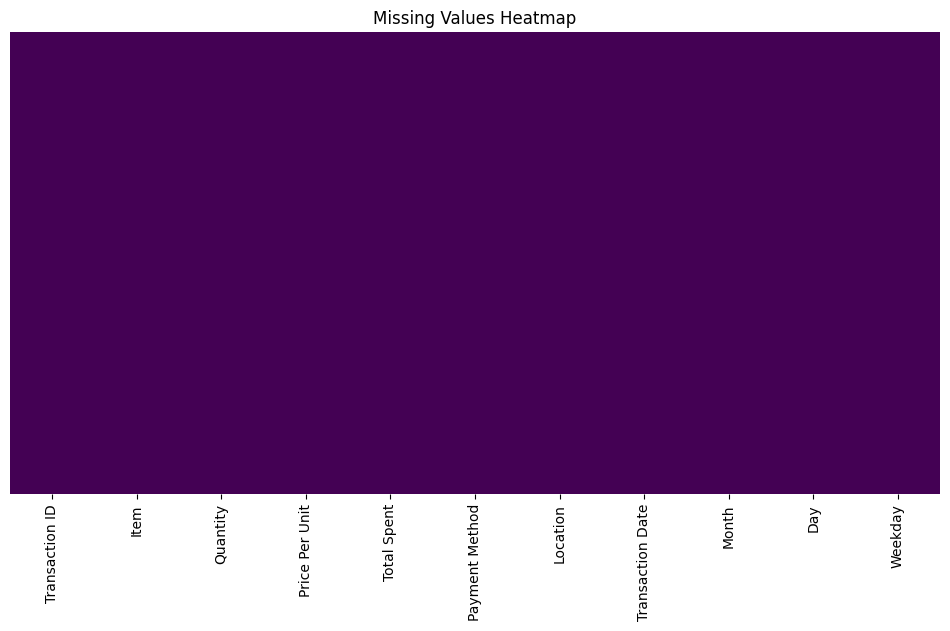

In [82]:
# Another test to see missingness - looks good!
plt.figure(figsize=(12,6))
sns.heatmap(cafedata.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [83]:
# Now we check if the imputations are reasonable
# 1.check that each item has the right unit price

menu_prices = {
    'Coffee': 2.0,
    'Tea': 1.5,
    'Sandwich': 4.0,
    'Salad': 5.0,
    'Cake': 3.0,
    'Cookie': 1.0,
    'Smoothie': 4.0,
    'Juice': 3.0
}

def check_price(row):
    expected_price = menu_prices.get(row['Item'])
    if expected_price is not None:
        return abs(row['Price Per Unit'] - expected_price) > 0.01
    return False

price_errors = cafedata[cafedata.apply(check_price, axis=1)]

# 2. check Price * Quantity = Total
total_errors = cafedata[abs(cafedata['Price Per Unit'] * cafedata['Quantity'] - cafedata['Total Spent']) > 0.01]

if len(price_errors) > 0:
    print("\n errors in match:")
    display(price_errors.head())

if len(total_errors) > 0:
    print("\n errors in equation")
    display(total_errors.head())
else:
    print("\n all good!")


 all good!


In [84]:
#OHE for later process
cafedata = pd.get_dummies(
    cafedata, 
    columns=['Item', 'Payment Method', 'Location'], 
    drop_first=True, 
    dtype=int
)

In [85]:
# A final sample to get a look at what our imputed data looks like. We're keeping the dummy variables around in case they're needed for future data analysis!
cafedata.sample(20)

,Transaction ID,Quantity,Price Per Unit,Total Spent,Transaction Date,Month,Day,Weekday,Item_Coffee,Item_Cookie,Item_Juice,Item_Salad,Item_Sandwich,Item_Smoothie,Item_Tea,Payment Method_Credit Card,Payment Method_Digital Wallet,Location_Takeaway
5479,TXN_6125646,2.0,1.0,2.0,2023-06-12,6,12,0,0,1,0,0,0,0,0,0,0,0
8012,TXN_8518516,4.0,4.0,16.0,2023-08-16,8,16,2,0,0,0,0,1,0,0,1,0,1
1797,TXN_2644962,2.0,4.0,8.0,2023-04-09,4,9,6,0,0,0,0,0,1,0,0,1,1
1303,TXN_2203873,3.0,1.5,4.5,2023-01-26,1,26,3,0,0,0,0,0,0,1,0,1,1
8975,TXN_9456575,5.0,1.5,7.5,2023-06-10,6,10,5,0,0,0,0,0,0,1,0,0,0
1377,TXN_2271705,5.0,1.5,7.5,2023-07-20,7,20,3,0,0,0,0,0,0,1,0,1,0
7309,TXN_7864080,5.0,1.5,7.5,2023-11-12,11,12,6,0,0,0,0,0,0,1,1,0,1
4727,TXN_5412834,4.0,4.0,16.0,2023-07-13,7,13,3,0,0,0,0,0,1,0,0,0,1
5034,TXN_5709834,4.0,3.0,12.0,2023-03-24,3,24,4,0,0,0,0,0,0,0,0,1,0
1398,TXN_2291079,1.0,2.0,2.0,2023-10-07,10,7,5,1,0,0,0,0,0,0,0,0,0


In [86]:
cafedata.shape

(9540, 18)

In [87]:
cafedata.to_csv('cleaned_cafe_sales.csv', index=False)

# Exploratory Data Analysis (EDA)

## Generate summary statistics and descriptive insights

In [ ]:
# basic structure
print("Dataset shape:", cafedata.shape)

# Field type & Non-null case
cafedata.info()

In [ ]:
# Missing rates in each column
missing_rate = cafedata.isna().mean().sort_values(ascending=False)
missing_rate

## Descriptive statistics of numerical variables

In [ ]:
numeric_cols = ['Total Spent', 'Quantity', 'Price Per Unit']
cafedata[numeric_cols].describe()

## Categorical variable frequency statistics

In [ ]:
categorical_cols = ['Item', 'Location', 'Payment Method']
for col in categorical_cols:
    print(f"\nFrequency of {col}:")
    print(cafedata[col].value_counts())

In [ ]:
total_revenue = cafedata['Total Spent'].sum()
avg_transaction_value = cafedata['Total Spent'].mean()
total_transactions = len(cafedata)
total_revenue, avg_transaction_value, total_transactions

Total revenue generated: $89306.5

Average transaction value: $8.93065

Number of transactions: 10000

## Numerical variable distribution (Histogram + KDE)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_cols = ['Total Spent', 'Quantity', 'Price Per Unit']
plt.figure(figsize=(15,4))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(cafedata[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Boxplot for Outliers

In [ ]:
plt.figure(figsize=(12,4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=cafedata[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

## Consumption distribution of different goods (Item × Total Spent)

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=cafedata,
    x='Item',
    y='Total Spent'
)
plt.xticks(rotation=45)
plt.title('Total Spent Distribution by Item')
plt.xlabel('Item')
plt.ylabel('Total Spent')
plt.show()

## Transaction frequency of Top Items

In [ ]:
item_counts = cafedata['Item'].value_counts()

plt.figure(figsize=(10, 6))
plt.vlines(x=item_counts.index, ymin=item_counts.min() - 10, ymax=item_counts.values, color='skyblue')
plt.plot(item_counts.index, item_counts.values, "o", markersize=8, color='steelblue')
plt.ylim(item_counts.min() - 20, item_counts.max() + 20)
for i, v in enumerate(item_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=45)
plt.title('Transaction Frequency by Item (Detailed Comparison)', pad=20)
plt.xlabel('Item')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Quantity × Total Spent

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=cafedata,
    x='Quantity',
    y='Total Spent',
    hue='Item',
    alpha=0.7
)
plt.title('Quantity vs Total Spent by Item')
plt.xlabel('Quantity')
plt.ylabel('Total Spent')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Price Per Unit × Total Spent

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=cafedata,
    x='Price Per Unit',
    y='Total Spent',
    alpha=0.6
)
plt.title('Price Per Unit vs Total Spent')
plt.xlabel('Price Per Unit')
plt.ylabel('Total Spent')
plt.show()

## Payment Method × Item

In [ ]:
payment_item = pd.crosstab(
    cafedata['Payment Method'],
    cafedata['Item'],
    normalize='index'
)

plt.figure(figsize=(10,5))
sns.heatmap(
    payment_item,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)
plt.title('Item Distribution by Payment Method')
plt.xlabel('Item')
plt.ylabel('Payment Method')
plt.show()

## Item × Location
Objective: To discover "certain products are more popular in certain locations".

In [ ]:
item_location = pd.crosstab(
    cafedata['Item'],
    cafedata['Location']
)

plt.figure(figsize=(8,6))
sns.heatmap(
    item_location,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Item Distribution across Locations')
plt.xlabel('Location')
plt.ylabel('Item')
plt.show()

## Visualize Trends

### Overall trend by "Date"

In [ ]:
daily_revenue = (
    cafedata
    .groupby('Transaction Date')['Total Spent']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(daily_revenue['Transaction Date'], daily_revenue['Total Spent'])
plt.title('Daily Total Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.show()

## Daily transaction trend

In [ ]:
daily_transactions = (
    cafedata
    .groupby('Transaction Date')
    .size()
    .reset_index(name='Transaction Count')
)

plt.figure(figsize=(10,5))
plt.plot(
    daily_transactions['Transaction Date'],
    daily_transactions['Transaction Count']
)
plt.title('Daily Number of Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Transaction Count')
plt.show()

## Average Transaction Value by Month

In [ ]:
monthly_avg = (
    cafedata
    .groupby('Month')['Total Spent']
    .mean()
    .reset_index()
)

plt.figure(figsize=(7,5))
sns.barplot(
    data=monthly_avg,
    x='Month',
    y='Total Spent'
)
plt.ylim(8.4, 9.5)
plt.title('Average Transaction Value by Month')
plt.xlabel('Month')
plt.ylabel('Average Total Spent')
plt.show()

In [ ]:
monthly_count = (
    cafedata
    .groupby('Month')
    .size()
    .reset_index(name='Transaction Count')
)

plt.figure(figsize=(7,5))
sns.barplot(
    data=monthly_count,
    x='Month',
    y='Transaction Count'
)
plt.ylim(700,1300)
plt.title('Transaction Volume by Month')
plt.xlabel('Month')
plt.ylabel('Transaction Count')
plt.show()

## Weekday Model

In [ ]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                 'Friday', 'Saturday', 'Sunday']

cafedata['Weekday_Name'] = cafedata['Transaction Date'].dt.day_name()

In [ ]:
weekday_count = (
    cafedata
    .groupby('Weekday_Name')
    .size()
    .reindex(weekday_order)
    .reset_index(name='Transaction Count')
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=weekday_count,
    x='Weekday_Name',
    y='Transaction Count'
)
plt.ylim(1200, 1900)
plt.title('Transaction Volume by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Transaction Count')
plt.show()

In [ ]:
weekday_avg = (
    cafedata
    .groupby('Weekday_Name')['Total Spent']
    .mean()
    .reindex(weekday_order)
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=weekday_avg,
    x='Weekday_Name',
    y='Total Spent'
)
plt.ylim(8.6,9.3)
plt.title('Average Spending by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Total Spent')
plt.show()

## Time × Product Trends

Purpose: To see "what sells when".

In [ ]:
item_month = pd.crosstab(
    cafedata['Month'],
    cafedata['Item'],
    normalize='index'
)

plt.figure(figsize=(10,6))
sns.heatmap(
    item_month,
    cmap='Blues'
)
plt.title('Item Distribution by Month')
plt.xlabel('Item')
plt.ylabel('Month')
plt.show()

## Patterns, Correlations, and Anomalies

In [ ]:
# Correlation
corr_vars = [
    'Quantity',
    'Price Per Unit',
    'Total Spent',
    'Month'
]

corr_matrix = cafedata[corr_vars].corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Correlation Matrix of Key Numerical Variables')
plt.show()

In [ ]:
# Error Distribution
cafedata['calc_error'] = (
    cafedata['Total Spent']
    - cafedata['Quantity'] * cafedata['Price Per Unit']
)

plt.figure(figsize=(7,5))
sns.histplot(
    cafedata['calc_error'],
    bins=30,
    kde=True
)
plt.title('Distribution of Total Spent Consistency Error')
plt.xlabel('Total Spent − (Quantity × Unit Price)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Outlier
threshold = cafedata['Total Spent'].quantile(0.99)

high_value_tx = cafedata[cafedata['Total Spent'] >= threshold]

plt.figure(figsize=(7,5))
sns.histplot(
    cafedata['Total Spent'],
    bins=30,
    kde=True
)
plt.axvline(
    threshold,
    color='red',
    linestyle='--',
    label='99th Percentile'
)
plt.legend()
plt.title('High-Value Transactions in Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.show()